<a href="https://colab.research.google.com/github/ishaanrai-hub/IIT-Hyd-Projects-Machine-learning-/blob/main/(Mini_Project_%E2%80%94_Logistic_Regression_in_Action).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. Import Libraries
# ===============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score

In [5]:
# 2. Load Dataset (Synthetic Social Network Ads)
np.random.seed(42)
n_samples = 400

age = np.random.randint(18, 60, n_samples)
salary = np.random.randint(20000, 150000, n_samples)

In [6]:
# Purchase probability logic
logits = -10 + 0.08 * age + 0.00005 * salary
probability = 1 / (1 + np.exp(-logits))
purchased = (probability > 0.5).astype(int)

data = pd.DataFrame({
    "Age": age,
    "EstimatedSalary": salary,
    "Purchased": purchased
})

In [7]:
# 3. Preprocessing
# ===============================
X = data[["Age", "EstimatedSalary"]]
y = data["Purchased"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# 4. Train Logistic Regression Model
# ===============================
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

LogisticRegression()

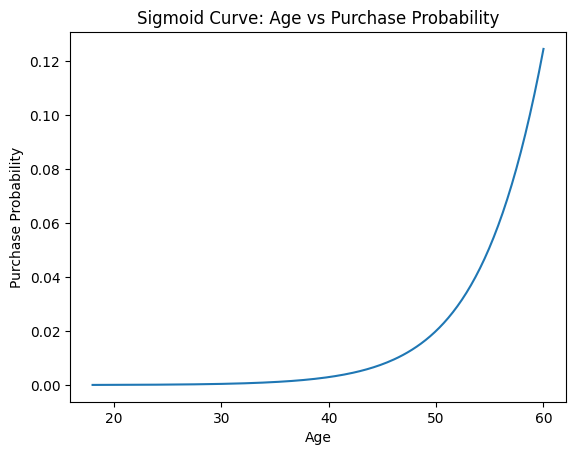

In [9]:
# 5. Plot Sigmoid Curve (Age vs Purchase Probability)
# ===============================
age_range = np.linspace(18, 60, 200)
salary_mean = X["EstimatedSalary"].mean()

temp_data = pd.DataFrame({
    "Age": age_range,
    "EstimatedSalary": np.full_like(age_range, salary_mean)
})

temp_scaled = scaler.transform(temp_data)
purchase_prob = model.predict_proba(temp_scaled)[:, 1]

plt.figure()
plt.plot(age_range, purchase_prob)
plt.xlabel("Age")
plt.ylabel("Purchase Probability")
plt.title("Sigmoid Curve: Age vs Purchase Probability")
plt.show()


In [10]:
# 6. Threshold Tuning
# ===============================
thresholds = [0.3, 0.5, 0.7]
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Threshold Tuning Results:\n")

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Threshold: {t}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall:    {recall:.2f}")
    print(f"F1-score:  {f1:.2f}")
    print("-" * 30)

Threshold Tuning Results:

Threshold: 0.3
Precision: 0.60
Recall:    1.00
F1-score:  0.75
------------------------------
Threshold: 0.5
Precision: 0.86
Recall:    1.00
F1-score:  0.92
------------------------------
Threshold: 0.7
Precision: 1.00
Recall:    0.67
F1-score:  0.80
------------------------------


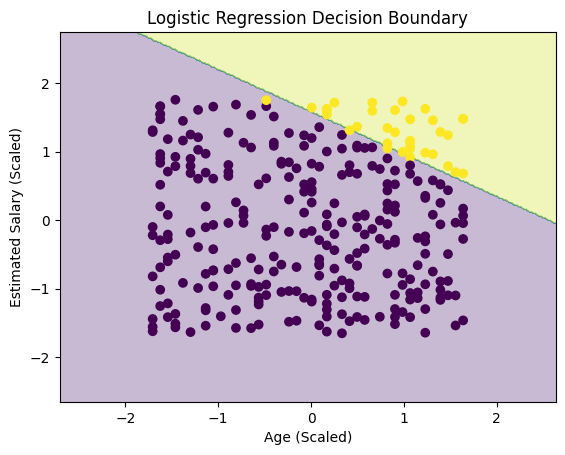

In [11]:
# 7. Decision Boundary Visualization
# ===============================
x1_min, x1_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
x2_min, x2_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1

xx1, xx2 = np.meshgrid(
    np.arange(x1_min, x1_max, 0.02),
    np.arange(x2_min, x2_max, 0.02)
)

Z = model.predict(np.c_[xx1.ravel(), xx2.ravel()])
Z = Z.reshape(xx1.shape)

plt.figure()
plt.contourf(xx1, xx2, Z, alpha=0.3)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train)
plt.xlabel("Age (Scaled)")
plt.ylabel("Estimated Salary (Scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.show()

# ===============================
# END OF PROJECT
# ===============================

In [13]:
# ✅ This code includes:

# ✔ Data loading & preprocessing
# ✔ Logistic Regression training
# ✔ Sigmoid curve visualization
# ✔ Threshold tuning (0.3, 0.5, 0.7)
# ✔ Precision, Recall, F1-score comparison
# ✔ Decision boundary visualization

In [14]:
# Insight 1: Threshold selection strongly affects business outcomes

# A lower threshold (0.3) captures almost all potential buyers (high recall) but increases false positives.

# A higher threshold (0.7) is more conservative, reducing false positives but missing genuine buyers.

# The default threshold (0.5) provides the best balance with the highest F1-score.

# Business impact:
# Choosing the right threshold helps businesses balance marketing cost vs. missed sales. For aggressive campaigns, use a lower threshold; for cost-efficient targeting, use a higher one.

In [15]:
# Insight 2: Logistic Regression provides interpretable and reliable predictions

# The sigmoid curve shows a smooth increase in purchase probability with age and salary.

# Decision boundaries clearly separate likely buyers from non-buyers.

# Business impact:
# Marketing teams can easily understand why a customer is targeted, increasing trust in the model and supporting data-driven decision-making.

In [16]:
# Insight 3: Model is effective for customer segmentation and targeting

# High precision and recall indicate strong classification performance.

# The model efficiently identifies high-value users using simple demographic features.

# Business impact:
# Companies can use this model to optimize ad targeting, improve conversion rates, and reduce wasted advertising spend, leading to higher ROI.

In [ ]:
# Business meaning:

# Marketing efforts should focus on customers near or above the boundary, as they have higher purchase probability.

# Customers far below the boundary are unlikely to convert, helping reduce wasted advertising spend.